In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

Скачайте файл с данными о публикациях на сайте Хабрахабр
(https://cloud.mail.ru/public/3ViL/q5xSM1TH2). Выполните следующие действия:
1. Изучите датасет, попробуйте понять какой столбец за что отвечает.
2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с
помощью filter() и удалите drop-ом:

In [79]:
df = pd.read_csv('howpop_train.csv', low_memory=False)
print(df.head())

                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

             published      author     flow polling content_len  \
0  2008-01-01 18:19:00      @Tapac  develop   False        4305   
1  2008-01-01 18:30:00  @DezmASter   design   False        7344   
2  2008-01-01 18:34:00  @DezmASter   design   False        8431   
3  2008-01-02 01:32:00    @Taoorus   design   False        5662   
4  2008-01-02 14:34:00    @dennydo      NaN   False        3706   

                                               title  comments  favs views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0     0   236   
1  Сумасшедшие яйца, или сервис для отслеживания ...         1     1

In [6]:
df.drop(
 filter(lambda c: c.endswith("_lognorm"), df.columns),
 axis=1, # axis = 1: столбцы
 inplace=True,
) # избавляет от необходимости сохранять датасет
print(df.head())

                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

             published      author     flow polling content_len  \
0  2008-01-01 18:19:00      @Tapac  develop   False        4305   
1  2008-01-01 18:30:00  @DezmASter   design   False        7344   
2  2008-01-01 18:34:00  @DezmASter   design   False        8431   
3  2008-01-02 01:32:00    @Taoorus   design   False        5662   
4  2008-01-02 14:34:00    @dennydo      NaN   False        3706   

                                               title  comments  favs views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0     0   236   
1  Сумасшедшие яйца, или сервис для отслеживания ...         1     1

3. Столбец published (время публикации) содержит строки. Чтобы работать с этими
данными как с датой/временем публикации, приведите их к типу datetime:


In [7]:
df["published"] = pd.to_datetime(df.published, yearfirst=True)
print(df.dtypes)

url                    object
domain                 object
post_id                 int64
published      datetime64[ns]
author                 object
flow                   object
polling                object
content_len            object
title                  object
comments                int64
favs                    int64
views                  object
votes_plus             object
votes_minus            object
Unnamed: 17            object
Unnamed: 18           float64
dtype: object


4. Создайте несколько столбцов на основе данных о времени публикации:


In [39]:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]
df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]
print(df.head())
print(df.dtypes)


                                url        domain  post_id  \
0  https://habrahabr.ru/post/18284/  habrahabr.ru    18284   
1  https://habrahabr.ru/post/18285/  habrahabr.ru    18285   
2  https://habrahabr.ru/post/18286/  habrahabr.ru    18286   
3  https://habrahabr.ru/post/18291/  habrahabr.ru    18291   
4  https://geektimes.ru/post/18294/  geektimes.ru    18294   

            published      author     flow polling content_len  \
0 2008-01-01 18:19:00      @Tapac  develop   False        4305   
1 2008-01-01 18:30:00  @DezmASter   design   False        7344   
2 2008-01-01 18:34:00  @DezmASter   design   False        8431   
3 2008-01-02 01:32:00    @Taoorus   design   False        5662   
4 2008-01-02 14:34:00    @dennydo      NaN   False        3706   

                                               title  comments  ...  views  \
0     Новогодний подарок блоггерам — WordPress 2.3.2         0  ...    236   
1  Сумасшедшие яйца, или сервис для отслеживания ...         1  ...    353

5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого
года) было больше всего публикаций.

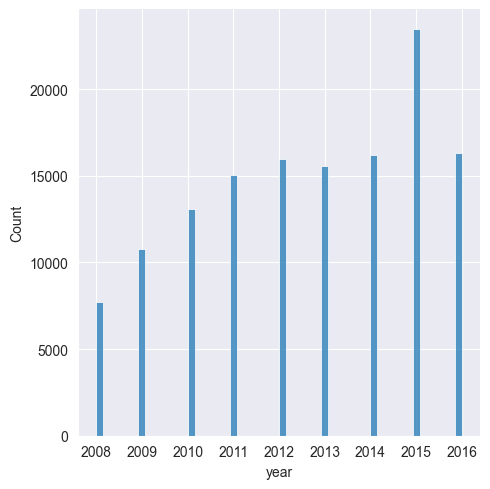

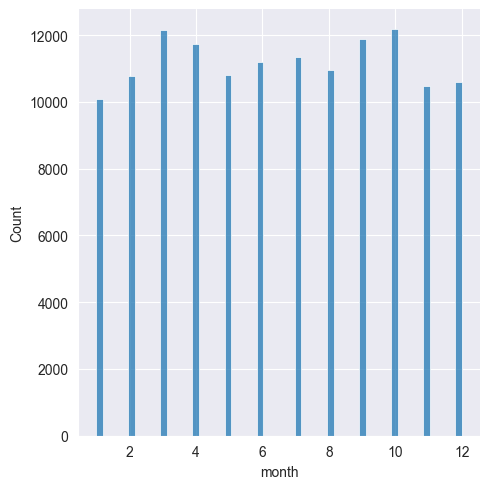

In [18]:
sb.displot(df['year'])
sb.displot(df['month'])


6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели,
используя параметр hue.

<Axes: xlabel='day_name', ylabel='count'>

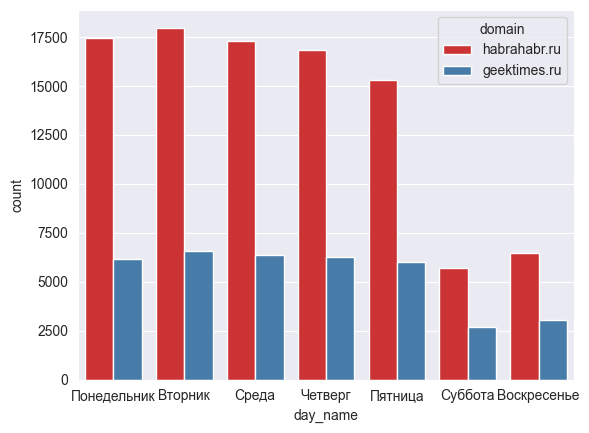

In [26]:
days_map = {
    1: 'Понедельник',
    2: 'Вторник',
    3: 'Среда',
    4: 'Четверг',
    5: 'Пятница',
    6: 'Суббота',
    7: 'Воскресенье'
}
df['day_name'] = df['dayofweek'].map(days_map)

sb.countplot(data=df, x='day_name', hue='domain',
              order=['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье'], palette='Set1')


Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения
про данный датасет:
-  Больше всего просмотров набирают статьи, опубликованные в 12 часов дня (нет)
-  У опубликованных в 10 утра постов больше всего комментариев (нет)
-  Больше всего просмотров набирают статьи, опубликованные в 6 часов утра (да)
- Максимальное число комментариев на гиктаймсе набрала статья,
опубликованная в 9 часов вечера  (нет)
- На хабре дневные статьи комментируют чаще, чем вечерние  (нет)

<Axes: xlabel='hour', ylabel='views'>

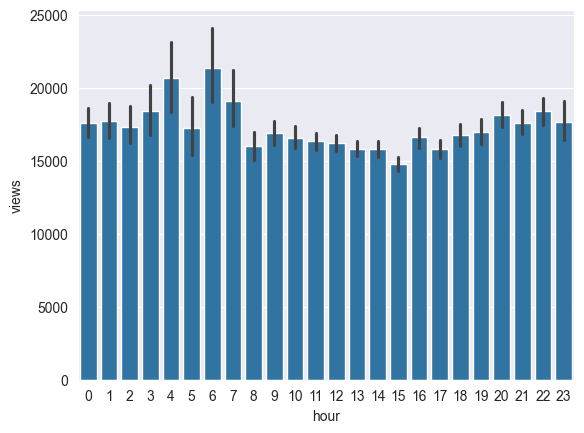

In [49]:
sb.barplot(x = "hour", y = "views", data = df)

<Axes: xlabel='hour', ylabel='comments'>

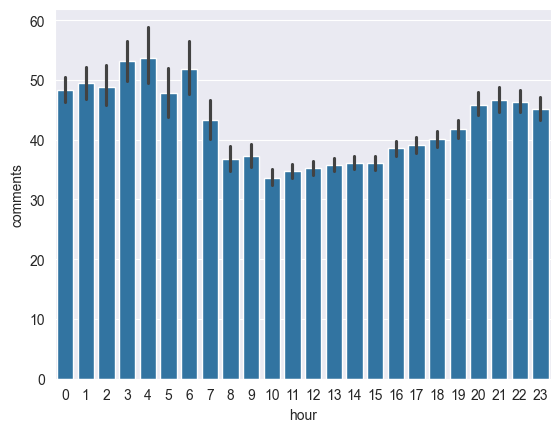

In [46]:
sb.barplot(x = "hour", y = "comments", data = df)

<Axes: xlabel='hour', ylabel='comments'>

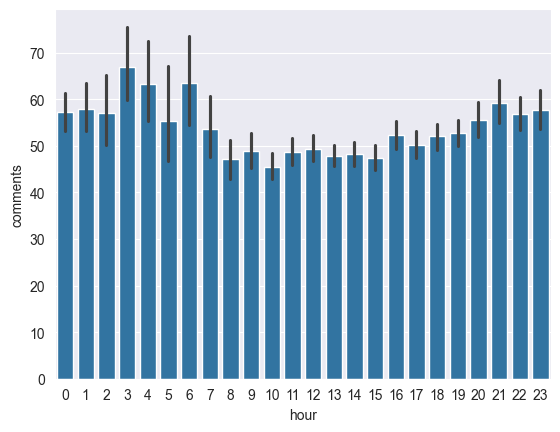

In [54]:
grouped = df.groupby(['hour'])
aggregated = grouped.agg({'comments': 'sum'})
filtered_df_ = df.loc[df['domain'] == 'geektimes.ru']
sb.barplot(x = "hour", y = "comments", data = filtered_df_)

<Axes: xlabel='hour', ylabel='comments'>

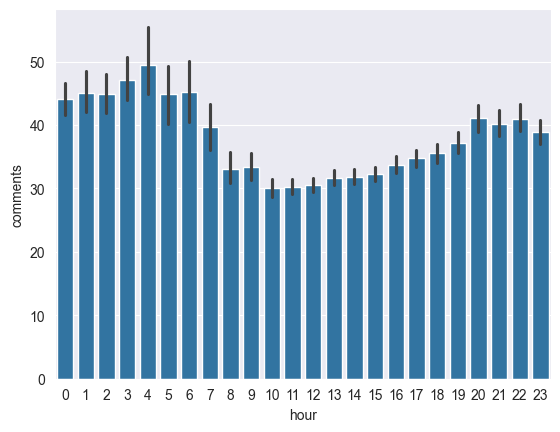

In [53]:
filtered_df = df.loc[df['domain'] == 'habrahabr.ru']
sb.barplot(x = "hour", y = "comments", data = filtered_df)

8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20
авторов чаще всего минусуют?


In [69]:

df["votes_plus"] = pd.to_numeric(df["votes_plus"])
print(df["votes_plus"].dtype)

float64


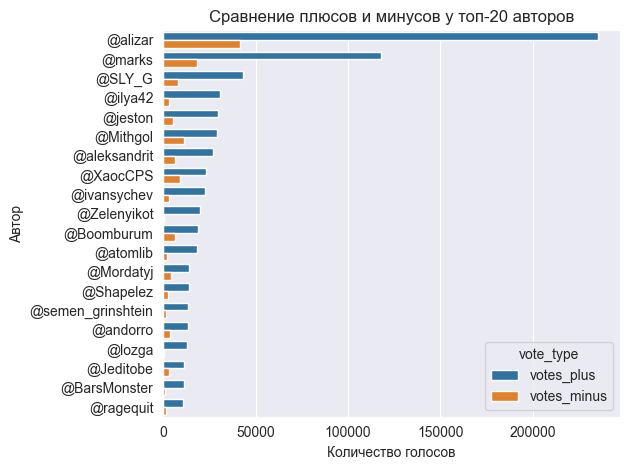

In [75]:
df_sorted = df.sort_values(by='votes_plus', ascending=False)
grouped = df.groupby('author')
aggregated = grouped.agg({
    'votes_plus': 'sum',
    'votes_minus': 'sum'
}).reset_index()

top_20_authors = aggregated.nlargest(20, 'votes_plus')

top_20_by_minus = top_20_authors.sort_values('votes_minus', ascending=False)

top_20_melted = pd.melt(top_20_authors,
                        id_vars=['author'],
                        value_vars=['votes_plus', 'votes_minus'],
                        var_name='vote_type',
                        value_name='count')
sb.barplot(data=top_20_melted, y='author', x='count', hue='vote_type')
plt.title('Сравнение плюсов и минусов у топ-20 авторов')
plt.xlabel('Количество голосов')
plt.ylabel('Автор')
plt.tight_layout()
plt.show()


9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам
авторы пишут в основном днём, а по понедельникам — в основном вечером?

Text(0, 0.5, 'Количество постов')

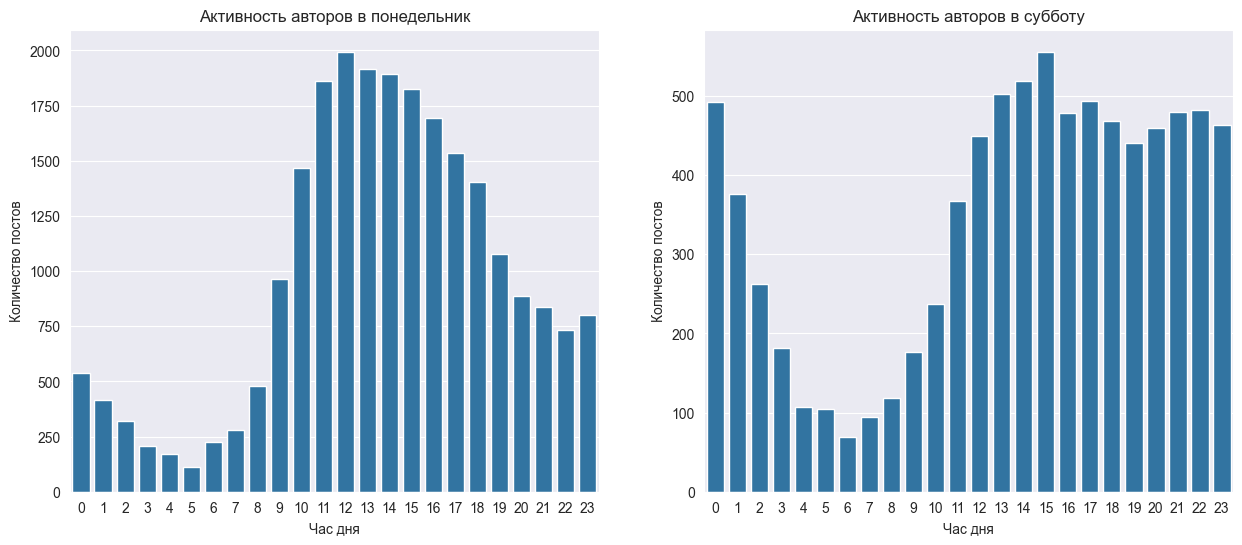

In [78]:
df_mon = df.loc[df['dayofweek'] == 1]
df_sut = df.loc[df['dayofweek'] == 6]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sb.countplot(data=df_mon, x='hour')
plt.title('Активность авторов в понедельник')
plt.xlabel('Час дня')
plt.ylabel('Количество постов')

plt.subplot(1, 2, 2)
sb.countplot(data=df_sut, x='hour')
plt.title('Активность авторов в субботу')
plt.xlabel('Час дня')
plt.ylabel('Количество постов')